# test_new_setup File Visualization and Comparison

This notebook loads binary files from `../test_new_setup/`, visualizes them, and compares their similarity.

Targets:
- `tones_real.bin`
- `soundbar_tones_real.bin`
- `monitor_tones_real.bin`

If your files are recorded at a different sample rate, update `SAMPLE_RATE` in Cell 2.

In [11]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import librosa
from scipy.signal import correlate, correlation_lags, csd, coherence, detrend, resample_poly, welch

plt.style.use('seaborn-v0_8-whitegrid')

BASE_DIR = Path('<REPO_ROOT>/baselines/test_new_setup')
SAMPLE_RATE = 200_000

INPUT_AUDIO_PATH = Path('<REPO_ROOT>/Audio Files/chirp_sweep.mp3')
OUTPUT_BIN_PATH = BASE_DIR / 'monitor_chirp.bin'

print(f'Input MP3:  {"FOUND" if INPUT_AUDIO_PATH.exists() else "MISSING"} ({INPUT_AUDIO_PATH})')
print(f'Output BIN: {"FOUND" if OUTPUT_BIN_PATH.exists() else "MISSING"} ({OUTPUT_BIN_PATH})')


Input MP3:  FOUND (<REPO_ROOT>/Audio Files/chirp_sweep.mp3)
Output BIN: FOUND (<REPO_ROOT>/baselines/test_new_setup/monitor_chirp.bin)


In [12]:
def load_chirp_mp3(path: Path, target_sr: int):
    signal, source_sr = librosa.load(path, sr=target_sr, mono=True)
    if signal.size == 0:
        raise ValueError(f'No samples loaded from {path}')
    signal = signal.astype(np.float64, copy=False)
    signal = signal - np.mean(signal)
    peak = np.max(np.abs(signal)) + 1e-12
    signal = signal / peak
    return signal, source_sr


def load_binary_float32(path: Path):
    signal = np.fromfile(path, dtype=np.float32)
    if signal.size == 0:
        raise ValueError(f'No samples loaded from {path}')
    signal = signal.astype(np.float64, copy=False)
    signal = signal - np.mean(signal)
    peak = np.max(np.abs(signal)) + 1e-12
    signal = signal / peak
    return signal


input_chirp, input_sr = load_chirp_mp3(INPUT_AUDIO_PATH, SAMPLE_RATE)
output_chirp = load_binary_float32(OUTPUT_BIN_PATH)

print(f'Input chirp samples:  {len(input_chirp):,} ({len(input_chirp)/SAMPLE_RATE:.2f}s at {input_sr} Hz)')
print(f'Output chirp samples: {len(output_chirp):,} ({len(output_chirp)/SAMPLE_RATE:.2f}s at {SAMPLE_RATE} Hz)')
print(f'Input peak abs:  {np.max(np.abs(input_chirp)):.6f}')
print(f'Output peak abs: {np.max(np.abs(output_chirp)):.6f}')


/users/<allocation>/user/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Input chirp samples:  36,000,000 (180.00s at 200000 Hz)
Output chirp samples: 37,000,000 (185.00s at 200000 Hz)
Input peak abs:  1.000000
Output peak abs: 1.000000


Estimated lag: 3,465,380 samples (17.326900 s)
Aligned overlap: 33,534,620 samples (167.67 s)


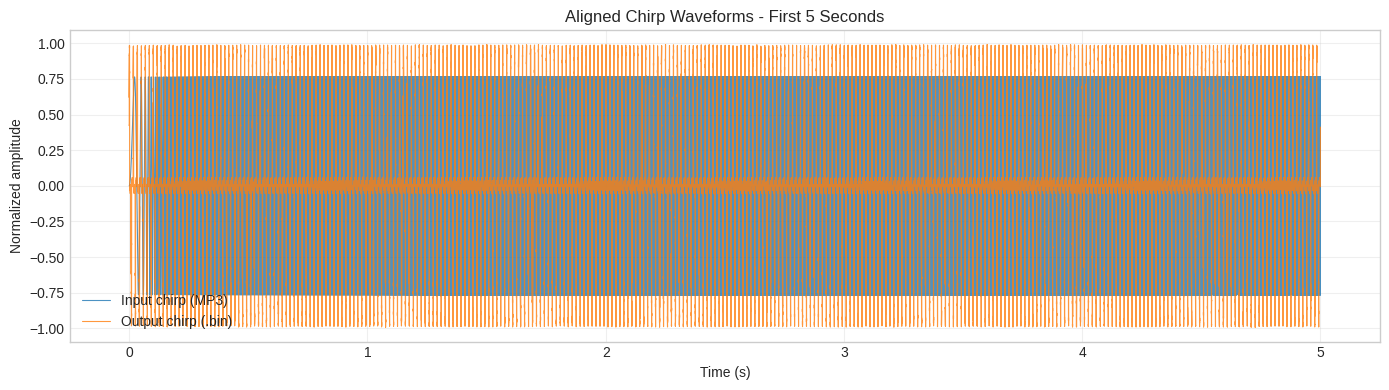

In [13]:
ALIGN_SEARCH_SEC = 20
DOWNSAMPLE_FACTOR = 20

search_len = min(len(input_chirp), len(output_chirp), ALIGN_SEARCH_SEC * SAMPLE_RATE)
input_ref = detrend(input_chirp[:search_len])
output_ref = detrend(output_chirp[:search_len])

input_ref_ds = resample_poly(input_ref, 1, DOWNSAMPLE_FACTOR)
output_ref_ds = resample_poly(output_ref, 1, DOWNSAMPLE_FACTOR)
corr = correlate(output_ref_ds, input_ref_ds, mode='full', method='fft')
lags = correlation_lags(len(output_ref_ds), len(input_ref_ds), mode='full')
lag_ds = int(lags[np.argmax(corr)])
lag_samples = lag_ds * DOWNSAMPLE_FACTOR

if lag_samples >= 0:
    input_start = 0
    output_start = lag_samples
else:
    input_start = -lag_samples
    output_start = 0

align_len = min(len(input_chirp) - input_start, len(output_chirp) - output_start)
input_aligned = input_chirp[input_start:input_start + align_len]
output_aligned = output_chirp[output_start:output_start + align_len]
alignment_delay_sec = lag_samples / SAMPLE_RATE

print(f'Estimated lag: {lag_samples:,} samples ({alignment_delay_sec:.6f} s)')
print(f'Aligned overlap: {align_len:,} samples ({align_len / SAMPLE_RATE:.2f} s)')

preview_sec = min(5, align_len / SAMPLE_RATE)
preview_samples = int(preview_sec * SAMPLE_RATE)
preview_t = np.arange(preview_samples) / SAMPLE_RATE

fig, ax = plt.subplots(1, 1, figsize=(14, 4))
ax.plot(preview_t, input_aligned[:preview_samples], label='Input chirp (MP3)', linewidth=0.8, alpha=0.8)
ax.plot(preview_t, output_aligned[:preview_samples], label='Output chirp (.bin)', linewidth=0.8, alpha=0.8)
ax.set_title('Aligned Chirp Waveforms - First 5 Seconds')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Normalized amplitude')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()

plt.tight_layout()
plt.show()

## Transfer Function Estimate

Estimate the frequency response after aligning the chirp input and output signals.

In [16]:
TF_NPERSEG = 16384
TF_NOVERLAP = TF_NPERSEG // 2

nperseg = min(TF_NPERSEG, len(input_aligned))
noverlap = min(TF_NOVERLAP, nperseg // 2)

freqs, pxy = csd(output_aligned, input_aligned, fs=SAMPLE_RATE, nperseg=nperseg, noverlap=noverlap, window='hann', scaling='density')
_, pxx = welch(input_aligned, fs=SAMPLE_RATE, nperseg=nperseg, noverlap=noverlap, window='hann', scaling='density')
_, pyy = welch(output_aligned, fs=SAMPLE_RATE, nperseg=nperseg, noverlap=noverlap, window='hann', scaling='density')

transfer = pxy / (pxx + 1e-20)
transfer_mag_db = 20 * np.log10(np.abs(transfer) + 1e-20)
transfer_phase = np.unwrap(np.angle(transfer))
input_psd_db = 10 * np.log10(pxx + 1e-20)
output_psd_db = 10 * np.log10(pyy + 1e-20)
reliable_mask = input_psd_db >= (np.max(input_psd_db) - 35)

print(f'Transfer function computed with {len(freqs)} frequency bins')
print(f'Input PSD median: {np.median(input_psd_db):.2f} dB')
print(f'Output PSD median: {np.median(output_psd_db):.2f} dB')
print(f'Reliable band bins: {np.count_nonzero(reliable_mask)} / {len(reliable_mask)}')

Transfer function computed with 8193 frequency bins
Input PSD median: -193.48 dB
Output PSD median: -116.69 dB
Reliable band bins: 828 / 8193


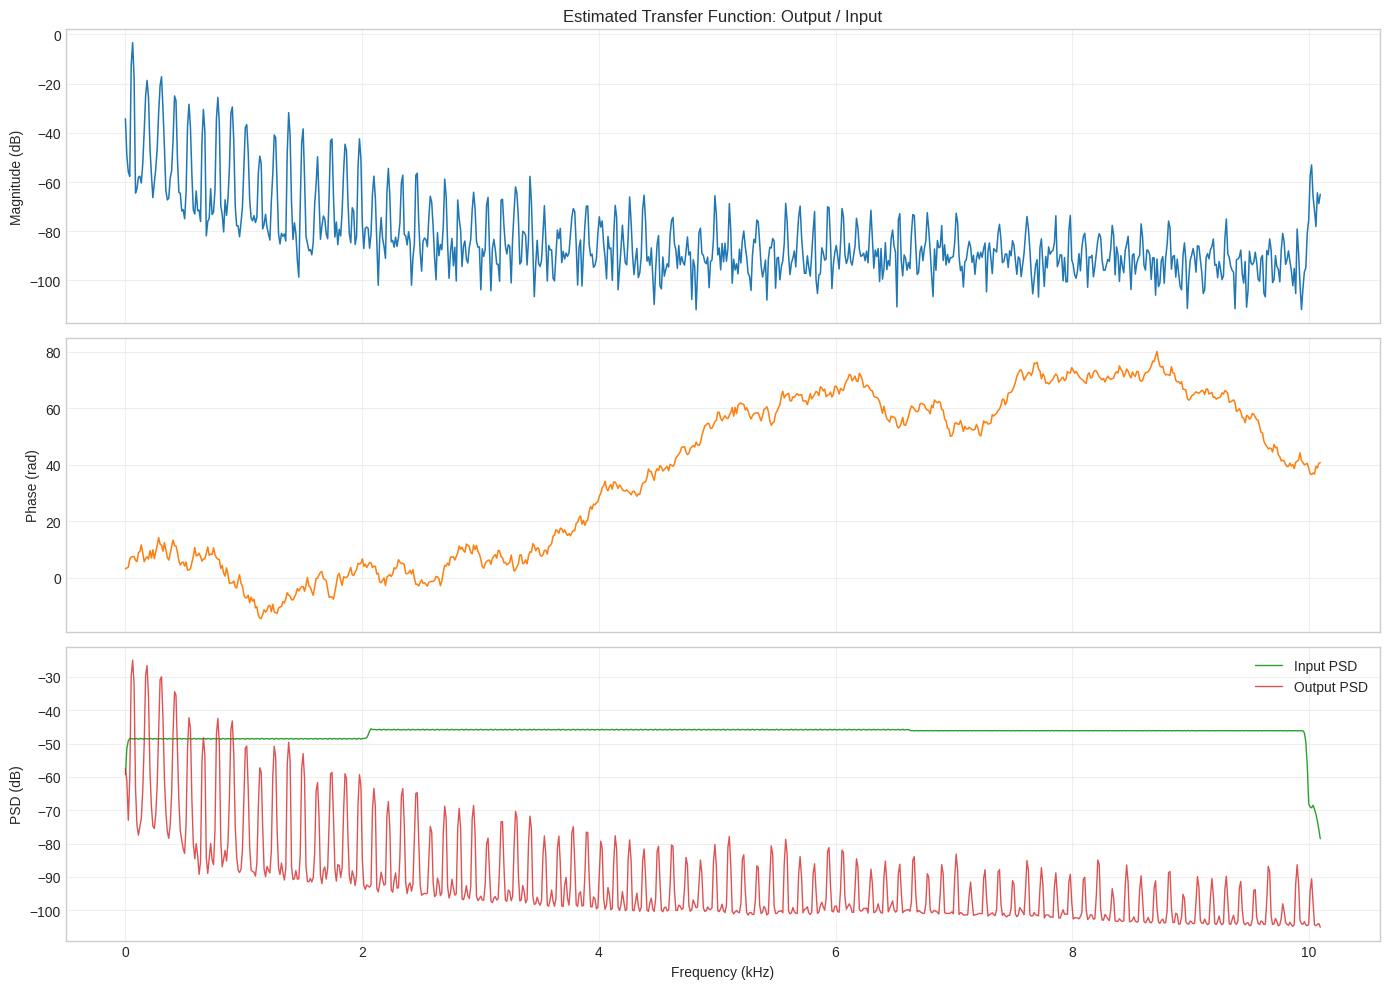

In [17]:
zoom_min_hz = 0
zoom_max_hz = 50_000
zoom_mask = (freqs >= zoom_min_hz) & (freqs <= zoom_max_hz) & reliable_mask

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(freqs[zoom_mask] / 1000, transfer_mag_db[zoom_mask], color='tab:blue', linewidth=1.1)
axes[0].set_ylabel('Magnitude (dB)')
axes[0].set_title('Estimated Transfer Function: Output / Input')
axes[0].grid(True, alpha=0.3)

axes[1].plot(freqs[zoom_mask] / 1000, transfer_phase[zoom_mask], color='tab:orange', linewidth=1.1)
axes[1].set_ylabel('Phase (rad)')
axes[1].grid(True, alpha=0.3)

axes[2].plot(freqs[zoom_mask] / 1000, input_psd_db[zoom_mask], color='tab:green', linewidth=1.0, label='Input PSD')
axes[2].plot(freqs[zoom_mask] / 1000, output_psd_db[zoom_mask], color='tab:red', linewidth=1.0, alpha=0.8, label='Output PSD')
axes[2].set_ylabel('PSD (dB)')
axes[2].set_xlabel('Frequency (kHz)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()